In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np

> ***personal note:***
>
> The `plot_function()` function visualizes a given function of a single variable over the interval $[a, b]$

In [ ]:
def _plot_function(f, a=-10, b=10, n=4096):
  xs = [a + (i * ((b - a) / n)) for i in range(n + 1)]
  ys = [f(x) for x in xs]
  plt.plot(xs, ys)
  plt.grid(True)
  plt.axhline(0, color='black', linewidth=0.8)
  plt.axvline(0, color='black', linewidth=0.8)
  plt.show()

> _**personal note:**_
>
> Numerical integration via **Simpson's rule** Approximates $\int_a^b f(x)\,dx$ by splitting $[a,b]$ into $n$ even panels and fitting a parabola through each consecutive triple of points.
>
> Each panel (3 points spaced by $h$) contributes:
>
> $$\int_{x_0}^{x_2} f(x)\,dx \approx \frac{h}{3}\left(f(x_0) + 4f(x_1) + f(x_2)\right)$$
>
> This method requires even $n$.

In [ ]:
def _integrate(f, a = -1024, b = 1024, n = 8192):
  result = 0
  for i in range(0, n - 1, 2):
    x0 = a + ((b - a) * (i / n))
    x1 = a + ((b - a) * ((i + 1) / n))
    x2 = a + ((b - a) * ((i + 2) / n))
    h = (b - a) / n
    cur_area = (h / 3) * ((f(x0) + (4 * f(x1)) + f(x2)))
    result += cur_area
  return result

We say that a *random variable*, $x$, is distributed according to a particular PDF. Let $p(x)$ be a PDF for the random variable, $x$, over the interval $[a, b]$. This is a nonnegative function that satisfies

$$\int_a^b p(x)\,dx = 1. \tag{2.1}$$

That is, it satisfies the *axiom of total probability*. Note that this is *probability density*, not *probability*.

In [ ]:
def _is_pdf(p, a = -1024, b = 1024):
  # check total area = 1
  if (abs(_simpson_integrate(p, a, b) - 1) < 0.001):
    # check nonnegativity
    for i in np.arange(a, b + 1, 0.125):
      if p(i) < 0:
        return False
    return True
  return False

Probability is given by the area under the density function. For example, the probability that $x$ lies between $c$ and $d$, $\Pr(c \leq x \leq d)$, is given by

$$\Pr(c \leq x \leq d) = \int_c^d p(x)\,dx. \tag{2.2}$$

In [ ]:
def _probability(p, c, d):
  return _simpson_integrate(p, c, d)

We will also make use of the *cumulative distribution function (CDF)* on occasion, which is given by

$$P(x) = \Pr(x' \leq x) = \int_{-\infty}^{x} p(x')\,dx', \tag{2.3}$$

In [ ]:
def _cdf(p):
  return lambda x: _simpson_integrate(p, -1024, x) #-inf bound to -1024 for brevity

> _**personal note:**_
>
> a *Gaussian distribution* is a PDF of the form
>
> $$p(x) = \frac{1}{\sigma\sqrt{2\pi}}\, e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$
>
> where $\mu$ is the mean and $\sigma$ the standard deviation.

In [ ]:
def _gaussian(mean, stdev):
  def gaussian(x):
    return (1 / (stdev * math.sqrt(2 * math.pi))) * math.exp(-0.5 * ((x - mean) / stdev) ** 2)
  return gaussian

We may also denote *joint probability densities* for $N$-dimensional continuous variables in our framework as $p(\mathbf{x})$, where $\mathbf{x} = (x_1, \dots, x_N)$ with $x_i \in [a_i, b_i]$. Note that we can also use the notation

$$p(x_1, x_2, \dots, x_N) \tag{2.5}$$

in place of $p(\mathbf{x})$.

In [ ]:
if __name__ == '__main__' and '__file__' not in globals():
  identity = lambda x: x #for brevity lets just assume values are equally distributed

  x = np.array([identity, identity, identity])
  px = np.array([_gaussian(0.0, 1.0), _gaussian(1.0, 2.0), _gaussian(-2.0, 0.5)])

Sometimes we even mix and match the two and write

$$p(\mathbf{x}, \mathbf{y}) \tag{2.6}$$

for the joint density of $\mathbf{x}$ and $\mathbf{y}$.

In [ ]:
if __name__ == '__main__' and '__file__' not in globals():
  x = np.array([identity, identity, identity])
  px = np.array([_gaussian(0.0, 1.0), _gaussian(1.0, 2.0), _gaussian(-2.0, 0.5)])

  y = np.array([identity, identity, identity])
  py = np.array([_gaussian(5.0, 2.5), _gaussian(-10.0, 1.2), _gaussian(0.0, 0.1)])

  xy = np.concatenate((x, y))
  pxy = np.concatenate((px, py))

<center>

**Testing/Playground Below** 

<small><em>
(always wrap with `if __name__ == '__main__' and '__file__' not in globals():`)
</em></small>

</center>

1.0
True


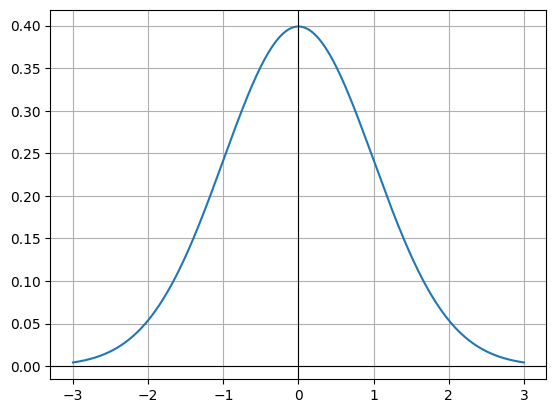

In [ ]:
if __name__ == '__main__' and '__file__' not in globals():
  std_normal = _gaussian(0.0, 1.0)
  print(_integrate(std_normal_dist))
  print(_is_pdf(std_normal_dist))
  _plot_function(std_normal_dist, -3, 3)